# 🗽 NYC Food Deserts
## Scripting for Data Analysis — Final Project
### Philippe Louis Jr.

---

## Overview

Imagining New York City as having "food deserts" almost seems like an oxymoron 
in a place known for its large population, unmatched diversity, and multitude of 
highly rated restaurants. Yet the reality is more complicated. What makes an area 
a food desert is not only the quantity of options available but the quality — and 
this report argues that the most widely used federal definition fails to capture 
either in a city like New York.

The USDA classifies a census tract as a food desert if it is both low income 
and more than 1 mile from a supermarket. By that definition, the Bronx has 
**zero food deserts**. Manhattan has **zero food deserts**. Queens has 
**zero food deserts**. Yet South Bronx has a 35.5% poverty rate, a 
grocery-to-fast-food ratio of 0.50, and 74% of its SNAP retailers are 
convenience stores rather than actual food stores. The USDA definition works 
in suburban environments where distance is the primary barrier. In a dense 
urban environment like NYC, there is almost always a supermarket within 1 mile 
— but that supermarket may be unaffordable, low quality, or surrounded by fast 
food chains and bodegas that have become the supplemental nutrition source for 
entire communities.

This project proposes and tests an alternative classification methodology built 
specifically for urban food environments — one that considers quantity, quality, 
affordability, and the ratio of healthy to unhealthy food options together. 
A composite Food Access Score is constructed from eight weighted variables 
spanning grocery density, fast food proliferation, health inspection grades, 
SNAP retailer quality, and farmers market access. The goal is not to replace 
the USDA definition but to expose its limitations in the context of NYC and 
offer a more defensible framework for identifying communities that are being 
left behind.

**Thesis:** The USDA's distance-based definition of food deserts systematically 
undercounts food insecurity in dense urban environments. In NYC, proximity to a 
supermarket does not equal access — quality, affordability, and the ratio of 
healthy to unhealthy food options must be considered together to accurately 
identify communities without meaningful access to nutritious food.

---

## Data Sources
- **Google Places API** — food establishment listings (grocery stores, restaurants, fast food, and bodegas) by neighborhood ZIP code
- **NYC Open Data — Restaurant Inspections** — official NYC Health Department inspection grades per establishment
- **U.S. Census ACS 5-Year Estimates** — population, median household income, and poverty rates by ZIP code
- **USDA Food Access Research Atlas (2019)** — federal food desert classification by census tract, used as a benchmark for comparison
- **NYC Open Data — Farmers Markets** — locations, EBT acceptance, and year-round status for all NYC farmers markets
- **USDA SNAP Retailer Locator** — all SNAP-authorized retailers by ZIP code including store type classification
- **MongoDB Atlas** — all raw and processed data stored and retrieved as JSON documents before any cleaning or transformation

---

## Neighborhoods Studied

27 neighborhoods across all five NYC boroughs were selected to represent a 
spectrum of income levels, food access conditions, and demographic profiles — 
from South Bronx and East New York to Park Slope and Tottenville.

| Neighborhood | Borough | My Classification | USDA Classification |
|---|---|---|---|
| South Bronx | Bronx | 🔴 Food Desert | ✅ Not a Desert |
| Highbridge | Bronx | 🟡 At Risk | ✅ Not a Desert |
| Belmont | Bronx | 🔴 Food Desert | ✅ Not a Desert |
| Riverdale | Bronx | 🟢 Good Access | ✅ Not a Desert |
| East New York | Brooklyn | 🟡 At Risk | 🏜️ Food Desert |
| Bedford-Stuyvesant | Brooklyn | 🔴 Food Desert | 🏜️ Food Desert |
| Crown Heights | Brooklyn | 🔴 Food Desert | 🏜️ Food Desert |
| Coney Island | Brooklyn | 🟡 At Risk | 🏜️ Food Desert |
| Bensonhurst | Brooklyn | 🟡 At Risk | 🏜️ Food Desert |
| Sheepshead Bay | Brooklyn | 🔴 Food Desert | 🏜️ Food Desert |
| Clinton Hill / Fort Greene | Brooklyn | 🔴 Food Desert | 🏜️ Food Desert |
| Red Hook | Brooklyn | 🟡 At Risk | 🏜️ Food Desert |
| Park Slope | Brooklyn | 🟢 Good Access | 🏜️ Food Desert |
| Midwood | Brooklyn | 🟡 At Risk | 🏜️ Food Desert |
| Washington Heights | Manhattan | 🟡 At Risk | ✅ Not a Desert |
| Harlem | Manhattan | 🔴 Food Desert | ✅ Not a Desert |
| Chinatown / Lower East Side | Manhattan | 🟡 At Risk | ✅ Not a Desert |
| Greenwich Village | Manhattan | 🟢 Good Access | ✅ Not a Desert |
| Upper West Side | Manhattan | 🟢 Good Access | ✅ Not a Desert |
| Astoria | Queens | 🟡 At Risk | ✅ Not a Desert |
| Jamaica | Queens | 🟡 At Risk | ✅ Not a Desert |
| Forest Hills | Queens | 🟡 At Risk | ✅ Not a Desert |
| Kew Gardens | Queens | 🟢 Good Access | ✅ Not a Desert |
| Middle Village | Queens | 🟢 Good Access | ✅ Not a Desert |
| Far Rockaway | Queens | 🟡 At Risk | ✅ Not a Desert |
| St. George | Staten Island | 🟡 At Risk | 🏜️ Food Desert |
| Tottenville | Staten Island | 🟢 Good Access | 🏜️ Food Desert |

---

> **Note on Methodology:** Neighborhoods are defined by ZIP code tabulation 
> areas (ZCTAs) rather than informal boundaries, ensuring consistency with 
> U.S. Census and NYC Open Data geographic keys. My classification uses a 
> composite Food Access Score built from eight weighted variables assigned 
> to one of three tiers — 🟢 Good Access (≥55), 🟡 At Risk (40-54), and 
> 🔴 Food Desert (<40). The USDA classification is based on the 2019 Food 
> Access Research Atlas using the LILATracts_1And10 flag — low income tracts 
> where at least 500 people or 33% of the population live more than 1 mile 
> from a supermarket. The divergence between the two classifications is a 
> central finding of this project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
import requests
from pymongo import MongoClient
import certifi
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings("ignore")

# Load environment variables
load_dotenv()

# MongoDB connection
MONGO_URI = os.getenv("MONGO_URI")
DB_NAME = "fooddesert"

client = MongoClient(MONGO_URI, tlsCAFile=certifi.where())
db = client[DB_NAME]

# Load all collections
places_df = pd.DataFrame(list(db["places"].find())).drop(columns=["_id"], errors="ignore")
inspections_df = pd.DataFrame(list(db["inspections"].find())).drop(columns=["_id"], errors="ignore")
census_df = pd.DataFrame(list(db["census"].find())).drop(columns=["_id"], errors="ignore")
usda_df = pd.DataFrame(list(db["usda"].find())).drop(columns=["_id"], errors="ignore")
farmers_df = pd.DataFrame(list(db["farmers_markets"].find())).drop(columns=["_id"], errors="ignore")
snap_df = pd.DataFrame(list(db["snap_retailers"].find())).drop(columns=["_id"], errors="ignore")
summary_df = pd.DataFrame(list(db["summary"].find())).drop(columns=["_id"], errors="ignore")

# Borough mapping
borough_map = {
    "South Bronx": "Bronx", "Highbridge": "Bronx", "Belmont": "Bronx", "Riverdale": "Bronx",
    "East New York": "Brooklyn", "Bedford-Stuyvesant": "Brooklyn", "Crown Heights": "Brooklyn",
    "Coney Island": "Brooklyn", "Bensonhurst": "Brooklyn", "Sheepshead Bay": "Brooklyn",
    "Clinton Hill / Fort Greene": "Brooklyn", "Red Hook": "Brooklyn", "Park Slope": "Brooklyn",
    "Midwood": "Brooklyn",
    "Washington Heights": "Manhattan", "Harlem": "Manhattan",
    "Chinatown / Lower East Side": "Manhattan", "Greenwich Village": "Manhattan",
    "Upper West Side": "Manhattan",
    "Astoria": "Queens", "Jamaica": "Queens", "Forest Hills": "Queens",
    "Kew Gardens": "Queens", "Middle Village": "Queens", "Far Rockaway": "Queens",
    "St. George": "Staten Island", "Tottenville": "Staten Island"
}

# Tier colors
tier_colors = {
    "Good Access": "#2ecc71",
    "At Risk": "#f39c12",
    "Food Desert": "#e74c3c"
}

# USDA borough summary
county_to_borough = {
    "New York County": "Manhattan", "Kings County": "Brooklyn",
    "Queens County": "Queens", "Bronx County": "Bronx",
    "Richmond County": "Staten Island"
}
nyc_counties = list(county_to_borough.keys())
usda_nyc = usda_df[usda_df["County"].isin(nyc_counties)].copy()
usda_nyc["borough"] = usda_nyc["County"].map(county_to_borough)

usda_borough = usda_nyc.groupby("borough").agg(
    total_tracts=("CensusTract", "count"),
    usda_food_deserts=("LILATracts_1And10", "sum"),
    low_income_tracts=("LowIncomeTracts", "sum"),
    avg_poverty_rate=("PovertyRate", "mean"),
    total_snap_recipients=("TractSNAP", "sum"),
    total_no_vehicle=("TractHUNV", "sum")
).reset_index()

usda_borough["pct_usda_food_desert"] = (
    usda_borough["usda_food_deserts"] / usda_borough["total_tracts"] * 100
).round(1)

# Verify
print(f"Places:          {len(places_df):,} records")
print(f"Inspections:     {len(inspections_df):,} records")
print(f"Census:          {len(census_df):,} records")
print(f"USDA:            {len(usda_df):,} records")
print(f"Farmers Markets: {len(farmers_df):,} records")
print(f"SNAP Retailers:  {len(snap_df):,} records")
print(f"Summary:         {len(summary_df):,} neighborhood records")
print(f"\n✅ All collections loaded successfully")
print(f"\nAccess Tier Distribution:")
print(summary_df["access_tier"].value_counts().to_string())

Places:          2,315 records
Inspections:     65,959 records
Census:          38 records
USDA:            2,227 records
Farmers Markets: 2,115 records
SNAP Retailers:  2,410 records
Summary:         27 neighborhood records

✅ All collections loaded successfully

Access Tier Distribution:
access_tier
At Risk        13
Food Desert     7
Good Access     7


---
## Data Collection

Six data sources were collected and stored directly into MongoDB Atlas as raw 
JSON documents before any cleaning or transformation:

1. **Google Places API** — queried by ZIP code for grocery stores, restaurants, 
fast food, and bodegas across 38 ZIP codes covering 27 neighborhoods. Stored 
in a `places` collection.

2. **NYC Open Data — Restaurant Inspections** — queried by ZIP code for 
inspection grades (A, B, C) and establishment details. Stored in an 
`inspections` collection.

3. **U.S. Census ACS 5-Year Estimates** — queried by ZCTA for total population, 
median household income, and poverty count. Stored in a `census` collection.

4. **USDA Food Access Research Atlas (2019)** — downloaded as Excel, filtered 
to NYC's five counties, and loaded via pandas. Includes the official food desert 
flag (`LILATracts_1And10`), poverty rate, SNAP recipients, and vehicle access. 
Serves as the federal benchmark for comparison. Stored in a `usda` collection.

5. **NYC Open Data — Farmers Markets** — queried for all active NYC market 
locations including EBT acceptance and year-round status. Matched to 
neighborhoods using geographic bounding boxes. Stored in a `farmers_markets` 
collection.

6. **USDA SNAP Retailer Locator** — queried by ZIP code for all authorized SNAP 
retailers including store type. Store type is the critical variable — it reveals 
whether food assistance dollars can be spent at actual food stores or only at 
convenience stores. Stored in a `snap_retailers` collection.

In [2]:
# Summary of raw data collected per neighborhood
print("📦 Google Places Data Collected by Neighborhood")
print("=" * 70)
raw_summary = places_df.groupby(["neighborhood", "search_type"]).size().unstack(fill_value=0)
col_order = [c for c in ["grocery store", "bodega", "fast food", "restaurant"] if c in raw_summary.columns]
raw_summary = raw_summary[col_order]
raw_summary.columns = ["Grocery Stores", "Bodegas", "Fast Food", "Restaurants"]
raw_summary["Total Places"] = raw_summary.sum(axis=1)
print(raw_summary.to_string())

print("\n\n🏥 Inspection Records Collected by Neighborhood")
print("=" * 70)
inspection_counts = inspections_df.groupby("neighborhood").size().reset_index(name="Total Inspections")
inspection_counts = inspection_counts.sort_values("Total Inspections", ascending=False)
print(inspection_counts.to_string(index=False))

print("\n\n👥 Census Data by Neighborhood")
print("=" * 70)
census_out = census_df.groupby("neighborhood").agg(
    total_population=("population", "sum"),
    avg_income=("median_income", "mean")
).reset_index()
census_out["avg_income"] = census_out["avg_income"].apply(lambda x: f"${x:,.0f}")
census_out["total_population"] = census_out["total_population"].apply(lambda x: f"{x:,}")
census_out = census_out.sort_values("neighborhood")
print(census_out.to_string(index=False))

print("\n\n🌽 Farmers Markets by Neighborhood")
print("=" * 70)
fm_out = farmers_df[farmers_df["neighborhood"].notna()].groupby("neighborhood").agg(
    total_markets=("marketname", "count"),
    ebt_accepted=("accepts_ebt", lambda x: (x == "Yes").sum()),
    year_round=("open_year_round", lambda x: (x == "Yes").sum())
).reset_index().sort_values("total_markets", ascending=False)
print(fm_out.to_string(index=False))

print("\n\n🏪 SNAP Retailers by Neighborhood")
print("=" * 70)
snap_out = snap_df.groupby(["neighborhood", "Store_Type"]).size().unstack(fill_value=0)
snap_out["Total"] = snap_out.sum(axis=1)
snap_out = snap_out.sort_values("Total", ascending=False)

# Rename columns to shorter names
snap_out.columns = [
    c.replace("Convenience Store", "Conv. Store")
     .replace("Farmers and Markets", "Farmers Mkt")
     .replace("Grocery Store", "Grocery")
     .replace("Restaurant Meals Program", "Rest. Meals")
     .replace("Specialty Store", "Specialty")
     .replace("Super Store", "Super Store")
     .replace("Supermarket", "Supermarket")
    for c in snap_out.columns
]

print(snap_out.to_string())

# Compute USDA borough summary directly in notebook
print("\n\n🗺️  USDA Food Desert Classification — NYC Borough Summary")
print("=" * 70)
nyc_counties = ["New York County", "Kings County", "Queens County", "Bronx County", "Richmond County"]
county_to_borough = {
    "New York County": "Manhattan", "Kings County": "Brooklyn",
    "Queens County": "Queens", "Bronx County": "Bronx",
    "Richmond County": "Staten Island"
}
usda_nyc = usda_df[usda_df["County"].isin(nyc_counties)].copy()
usda_nyc["borough"] = usda_nyc["County"].map(county_to_borough)

usda_borough = usda_nyc.groupby("borough").agg(
    total_tracts=("CensusTract", "count"),
    usda_food_deserts=("LILATracts_1And10", "sum"),
    low_income_tracts=("LowIncomeTracts", "sum"),
    avg_poverty_rate=("PovertyRate", "mean"),
    total_snap_recipients=("TractSNAP", "sum"),
    total_no_vehicle=("TractHUNV", "sum")
).reset_index()
usda_borough["pct_usda_food_desert"] = (
    usda_borough["usda_food_deserts"] / usda_borough["total_tracts"] * 100
).round(1)

print(usda_borough[["borough", "total_tracts", "usda_food_deserts",
                     "pct_usda_food_desert", "avg_poverty_rate",
                     "total_snap_recipients", "total_no_vehicle"]].to_string(index=False))

📦 Google Places Data Collected by Neighborhood
                             Grocery Stores  Bodegas  Fast Food  Restaurants  Total Places
neighborhood                                                                              
Astoria                                  26       26         31           32           115
Bedford-Stuyvesant                       18       15         32           31            96
Belmont                                  19       19         19           19            76
Bensonhurst                              19        9         20           19            67
Chinatown / Lower East Side              17       20         20           20            77
Clinton Hill / Fort Greene               25       16         34           35           110
Coney Island                             19        3         20           15            57
Crown Heights                            15        9         18           14            56
East New York                            34

---
## Data Cleaning & Merging

All six collections were pulled from MongoDB into pandas DataFrames and 
processed as follows: Places deduplicated on `place_id` with population-normalized 
metrics computed per 10,000 residents — bodega data was excluded from scoring 
after Google's search was found to miscategorize suburban convenience stores. 
Inspections deduplicated on `camis` keeping only the most recent grade per 
restaurant. Census aggregated across ZIP codes for total population, income, 
and poverty rate. USDA data filtered to NYC's five counties with the 
`LILATracts_1And10` flag used as the federal benchmark. Farmers markets matched 
to neighborhoods via geographic bounding boxes. SNAP retailers aggregated by 
store type to compute a `snap_healthy_ratio` — the percentage of SNAP retailers 
that are actual food stores rather than convenience stores. All six datasets 
were then merged on neighborhood name, normalized by population, and written 
back to MongoDB as a `summary` collection.

---

## Food Access Score Methodology

Rather than a single threshold like the USDA's 1-mile rule, this project 
constructs a composite **Food Access Score** from eight weighted variables:

| Variable | Weight | Direction | Description |
|---|---|---|---|
| Grocery stores per 10k | ×10 | ➕ | Primary measure of physical food access — the most direct indicator of whether a neighborhood has meaningful grocery options relative to its population |
| Fast food per 10k | ×6 | ➖ | High fast food density signals a food environment dominated by cheap, calorie-dense options — the strongest negative indicator in the model |
| SNAP healthy retailer ratio | ×0.5 | ➕ | Percentage of SNAP-authorized retailers that are actual food stores vs convenience stores — measures whether food assistance dollars can buy nutritious food |
| Year-round farmers markets | ×1.5 | ➕ | Markets open all year provide consistent fresh produce access — seasonal markets alone cannot serve as a reliable food source |
| Farmers markets per 10k | ×1 | ➕ | Population-normalized market density — ensures a neighborhood with many markets but a large population isn't over-credited |
| % Grade A inspections | ×0.2 | ➕ | Official NYC Health Department grade reflects baseline food establishment quality and safety standards |
| % EBT-accepting markets | ×0.1 | ➕ | Farmers markets that accept EBT make fresh produce accessible to low-income residents — without EBT acceptance a market serves only wealthier shoppers |
| Poverty rate | ×0.3 | ➖ | High poverty structurally limits food access even when stores are physically present — residents may be unable to afford quality food regardless of proximity |

Neighborhoods are assigned to one of three tiers:
- 🟢 **Good Access** — score ≥ 55
- 🟡 **At Risk** — score 40–54
- 🔴 **Food Desert** — score < 40

In [3]:
# Master summary table
display_cols = {
    "neighborhood": "Neighborhood",
    "borough": "Borough",
    "total_population": "Population",
    "avg_median_income": "Avg Income",
    "poverty_rate": "Poverty Rate (%)",
    "grocery_per_10k": "Groceries per 10k",
    "fastfood_per_10k": "Fast Food per 10k",
    "grocery_to_fastfood_ratio": "Grocery/FastFood Ratio",
    "total_farmers_markets": "Farmers Markets",
    "year_round_markets": "Year-Round Markets",
    "snap_healthy_ratio": "SNAP Healthy (%)",
    "pct_grade_A": "% Grade A",
    "food_access_score": "Food Access Score",
    "access_tier": "Access Tier",
    "usda_food_desert": "USDA Classification"
}

display_df = summary_df[[c for c in display_cols.keys() if c in summary_df.columns]].rename(columns=display_cols)
display_df["Avg Income"] = display_df["Avg Income"].apply(lambda x: f"${x:,.0f}")
display_df["Population"] = display_df["Population"].apply(lambda x: f"{x:,.0f}")
display_df["Access Tier"] = display_df["Access Tier"].apply(lambda x:
    "🟢 Good Access" if x == "Good Access" else
    "🟡 At Risk" if x == "At Risk" else
    "🔴 Food Desert"
)
display_df["USDA Classification"] = display_df["USDA Classification"].apply(
    lambda x: "🏜️ Food Desert" if x else "✅ Not a Desert"
)
display_df = display_df.sort_values("Food Access Score", ascending=False)

display_df

,Neighborhood,Borough,Population,Avg Income,Poverty Rate (%),Groceries per 10k,Fast Food per 10k,Grocery/FastFood Ratio,Farmers Markets,Year-Round Markets,SNAP Healthy (%),% Grade A,Food Access Score,Access Tier,USDA Classification
24,Tottenville,Staten Island,"14,821","$138,807",2.7,13.49,13.49,1.00,0.0,0.0,33.3,87.0,87.20,🟢 Good Access,🏜️ Food Desert
25,Upper West Side,Manhattan,"130,044","$170,240",8.0,2.00,2.85,0.70,27.0,19.0,54.8,94.2,77.32,🟢 Good Access,✅ Not a Desert
20,Riverdale,Bronx,"23,400","$108,738",5.4,7.26,7.26,1.00,13.0,1.0,37.5,90.0,71.23,🟢 Good Access,✅ Not a Desert
18,Park Slope,Brooklyn,"113,491","$169,544",7.5,3.00,3.35,0.90,11.0,10.0,43.3,93.4,63.95,🟢 Good Access,🏜️ Food Desert
11,Greenwich Village,Manhattan,"53,825","$153,750",10.4,2.97,3.72,0.80,23.0,7.0,43.3,94.4,59.56,🟢 Good Access,✅ Not a Desert
15,Kew Gardens,Queens,"21,379","$88,632",9.3,8.42,9.35,0.90,4.0,0.0,21.4,93.8,56.64,🟢 Good Access,✅ Not a Desert
16,Middle Village,Queens,"37,378","$92,509",7.2,4.82,5.08,0.95,0.0,0.0,41.2,96.6,55.48,🟢 Good Access,✅ Not a Desert
10,Forest Hills,Queens,"75,320","$104,319",7.9,1.59,2.52,0.63,8.0,7.0,50.0,93.1,53.59,🟡 At Risk,✅ Not a Desert
0,Astoria,Queens,"63,706","$97,892",11.1,4.08,4.87,0.84,11.0,0.0,46.8,93.1,52.00,🟡 At Risk,✅ Not a Desert
26,Washington Heights,Manhattan,"109,190","$66,086",18.2,2.11,3.02,0.70,27.0,6.0,48.1,93.0,51.64,🟡 At Risk,✅ Not a Desert


---
## Analysis





### Q1: How do NYC neighborhoods rank on food access and what tier do they fall into?

The Food Access Score ranks all 27 neighborhoods using six weighted variables — 
grocery density, fast food density, health inspection grades, SNAP retailer 
quality, year-round farmers market access, and poverty rate — then assigns 
each to one of three tiers:

- 🟢 **Good Access (≥55)** — strong grocery density, manageable fast food concentration
- 🟡 **At Risk (40–54)** — moderate challenges with clear warning signs
- 🔴 **Food Desert (<40)** — low grocery density, high fast food, high poverty, poor SNAP retailer quality

Of 27 neighborhoods, **7 are Good Access, 13 are At Risk, and 7 are Food 
Deserts**. Scores range from Tottenville (87.20) to South Bronx (27.39), 
where fast food outnumbers grocery stores two to one and only 36.6% of SNAP 
retailers are actual food stores. The At Risk tier is the most critical policy 
finding — 13 neighborhoods are not yet food deserts but show warning signs, 
with East New York, Highbridge, and Crown Heights sitting just above the 
threshold and vulnerable to tipping over as gentrification reshapes the 
food retail landscape.

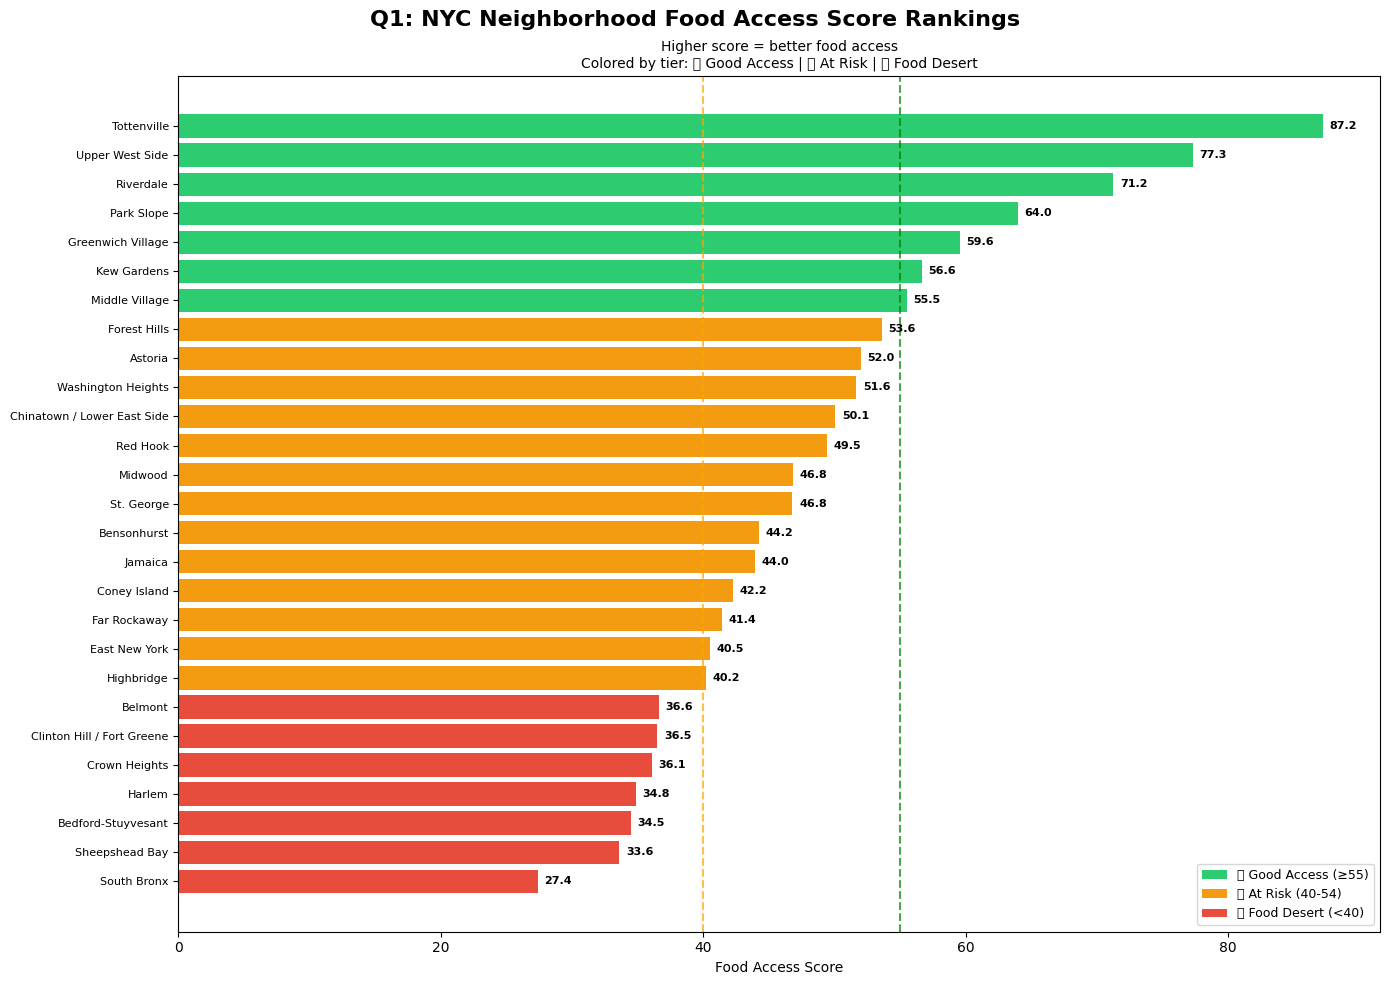

✅ Chart saved


In [4]:
# Q1 - Food Access Score Ranking
fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle("Q1: NYC Neighborhood Food Access Score Rankings", 
             fontsize=16, fontweight="bold")

q1_df = summary_df.sort_values("food_access_score", ascending=True)
colors = [tier_colors[t] for t in q1_df["access_tier"]]

bars = ax.barh(q1_df["neighborhood"], q1_df["food_access_score"], color=colors)

# Add threshold lines
ax.axvline(x=55, color="green", linestyle="--", linewidth=1.5, alpha=0.7, label="Good Access threshold (55)")
ax.axvline(x=40, color="orange", linestyle="--", linewidth=1.5, alpha=0.7, label="At Risk threshold (40)")

# Add score labels
for bar, val in zip(bars, q1_df["food_access_score"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=8, fontweight="bold")

ax.set_xlabel("Food Access Score")
ax.set_title("Higher score = better food access\nColored by tier: 🟢 Good Access | 🟡 At Risk | 🔴 Food Desert",
             fontsize=10)
ax.tick_params(axis="y", labelsize=8)
ax.legend(fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="🟢 Good Access (≥55)"),
    Patch(facecolor="#f39c12", label="🟡 At Risk (40-54)"),
    Patch(facecolor="#e74c3c", label="🔴 Food Desert (<40)")
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("q1_food_access_score.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")


---
### Q2: Where does the USDA definition fail NYC?

The USDA classifies a food desert as a low income census tract more than 
1 mile from a supermarket. By that definition the Bronx, Manhattan, and 
Queens each have **zero food deserts** — yet South Bronx scores 27.39 on 
our scale and has a 35.5% poverty rate. Staten Island, the wealthiest 
borough, accounts for 28 of NYC's 33 USDA food deserts simply because its 
suburban layout stretches distances beyond 1 mile.

The 1-mile threshold was designed for rural and suburban America. In NYC, 
there is almost always a supermarket within 1 mile — but that supermarket 
may be unaffordable, low quality, or surrounded by fast food and convenience 
stores that serve as the practical default. Proximity is not the same as 
access. The chart below shows exactly where the two classifications diverge 
and why.

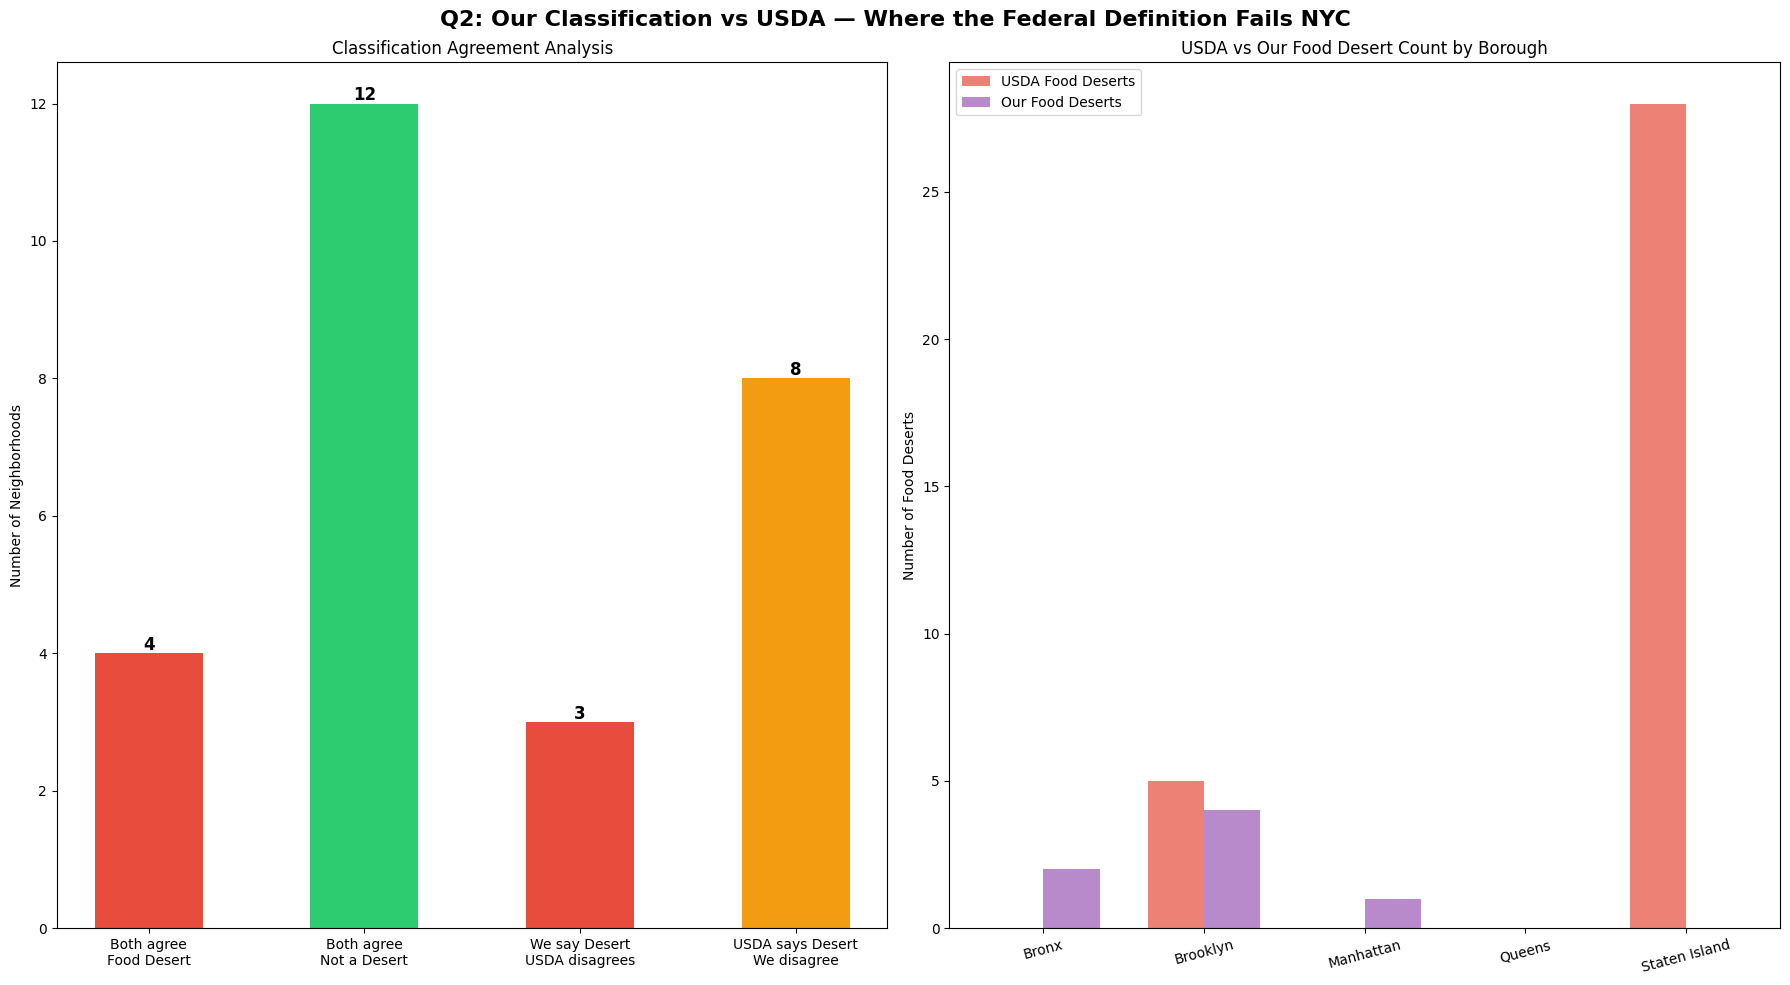

✅ Chart saved


In [5]:
# Q2 - USDA vs Our Classification Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle("Q2: Our Classification vs USDA — Where the Federal Definition Fails NYC",
             fontsize=16, fontweight="bold")

# Chart 1 - Disagreement breakdown
agree_desert = len(summary_df[(summary_df["access_tier"] == "Food Desert") & (summary_df["usda_food_desert"] == True)])
agree_non_desert = len(summary_df[(summary_df["access_tier"] != "Food Desert") & (summary_df["usda_food_desert"] == False)])
we_say_desert_usda_disagrees = len(summary_df[(summary_df["access_tier"] == "Food Desert") & (summary_df["usda_food_desert"] == False)])
usda_says_desert_we_disagree = len(summary_df[(summary_df["access_tier"] != "Food Desert") & (summary_df["usda_food_desert"] == True)])

categories = ["Both agree\nFood Desert", "Both agree\nNot a Desert", 
              "We say Desert\nUSDA disagrees", "USDA says Desert\nWe disagree"]
values = [agree_desert, agree_non_desert, we_say_desert_usda_disagrees, usda_says_desert_we_disagree]
bar_colors = ["#e74c3c", "#2ecc71", "#e74c3c", "#f39c12"]

bars = axes[0].bar(categories, values, color=bar_colors, width=0.5)
axes[0].set_title("Classification Agreement Analysis")
axes[0].set_ylabel("Number of Neighborhoods")
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                f"{val}", ha="center", fontsize=12, fontweight="bold")

# Chart 2 - Borough level USDA vs reality
borough_order = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
borough_colors_list = ["#9b59b6", "#3498db", "#e67e22", "#1abc9c", "#e74c3c"]

usda_by_borough = usda_borough.set_index("borough").reindex(borough_order)
our_by_borough = summary_df.groupby("borough").agg(
    food_deserts=("our_food_desert", "sum"),
    total=("neighborhood", "count")
).reindex(borough_order)

x = range(len(borough_order))
width = 0.35

axes[1].bar([i - width/2 for i in x], usda_by_borough["usda_food_deserts"],
            width, label="USDA Food Deserts", color="#e74c3c", alpha=0.7)
axes[1].bar([i + width/2 for i in x], our_by_borough["food_deserts"],
            width, label="Our Food Deserts", color="#9b59b6", alpha=0.7)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(borough_order, rotation=15)
axes[1].set_title("USDA vs Our Food Desert Count by Borough")
axes[1].set_ylabel("Number of Food Deserts")
axes[1].legend()

plt.tight_layout()
plt.savefig("q2_usda_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

---
### Q3: What variables are driving food desert status?

Understanding why a neighborhood scores where it does requires breaking down 
the individual components of the Food Access Score across the three tiers. 
If the methodology is sound, Food Desert neighborhoods should consistently 
show low grocery density, high fast food concentration, low SNAP healthy 
ratios, and limited year-round farmers market access — while Good Access 
neighborhoods show the opposite pattern.

The chart below compares the average value of each key variable across the 
three tiers. The gaps between tiers reveal which variables are the strongest 
predictors of food desert status and which are less discriminating. A variable 
that looks similar across all three tiers is a weak signal — a variable that 
shows a clear gradient from Food Desert to Good Access is doing real analytical 
work in the score.

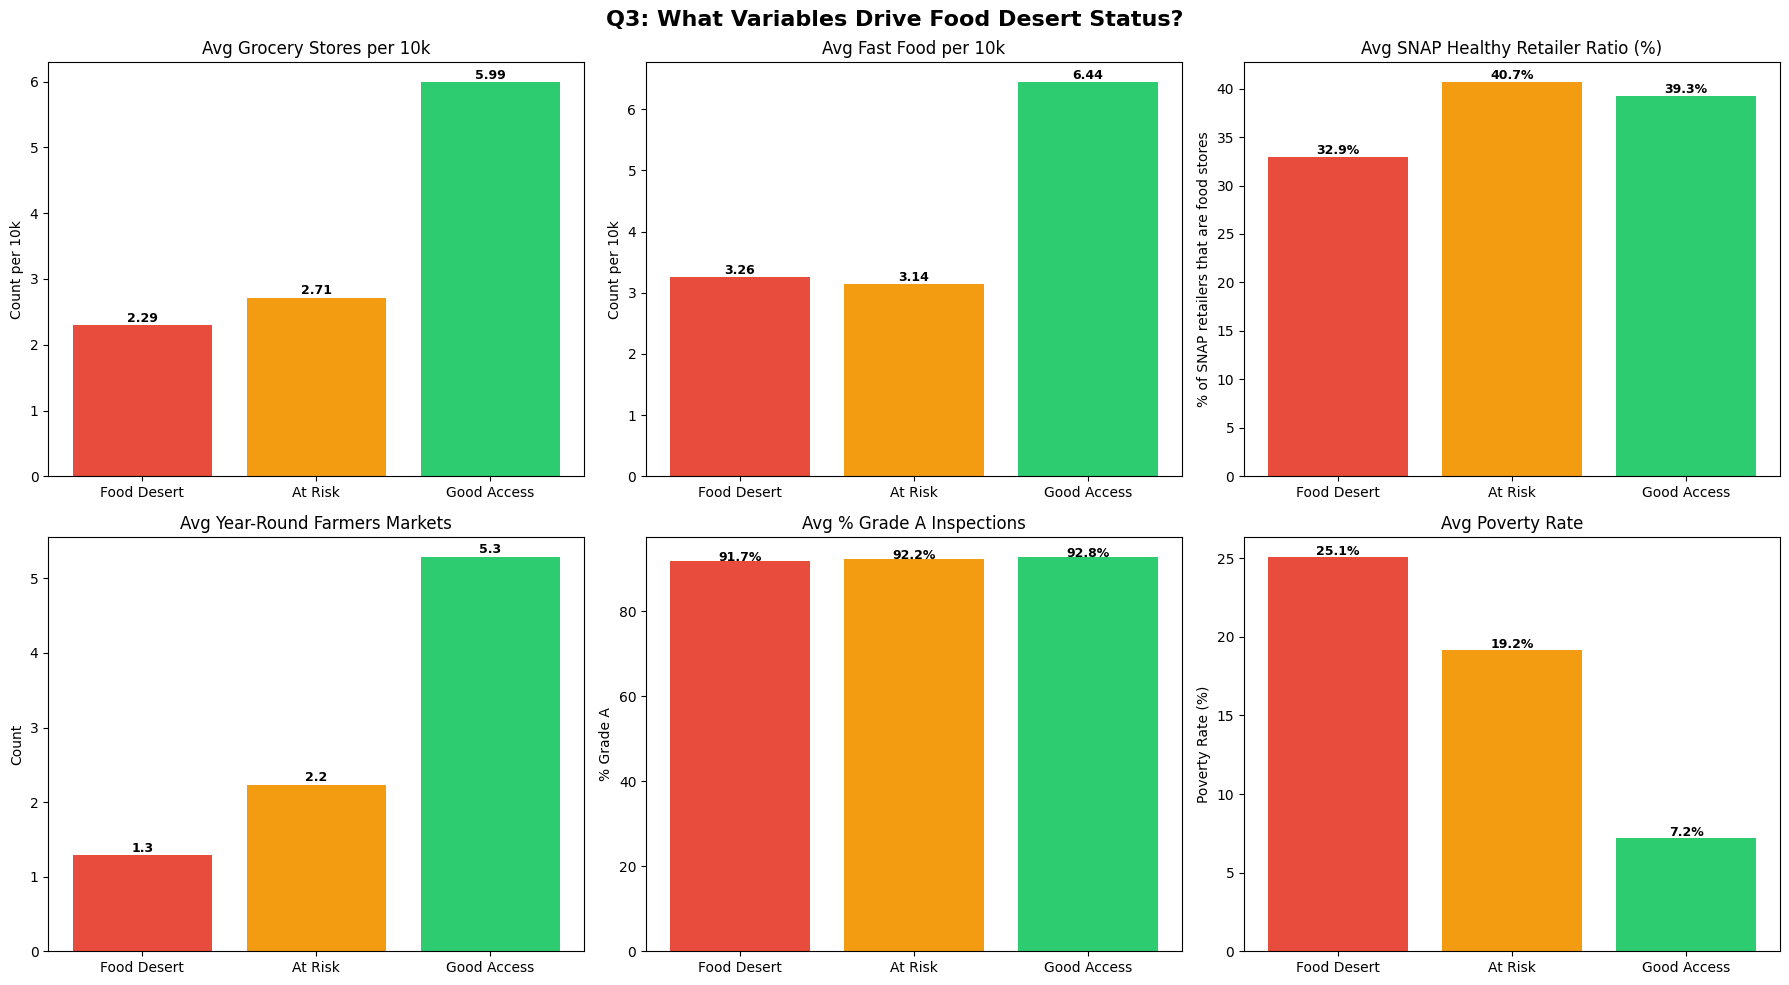

✅ Chart saved


In [6]:
# Q3 - Score Components by Access Tier
tier_order = ["Food Desert", "At Risk", "Good Access"]

q3_df = summary_df.groupby("access_tier").agg(
    avg_grocery_per_10k=("grocery_per_10k", "mean"),
    avg_fastfood_per_10k=("fastfood_per_10k", "mean"),
    avg_snap_healthy=("snap_healthy_ratio", "mean"),
    avg_year_round=("year_round_markets", "mean"),
    avg_pct_grade_A=("pct_grade_A", "mean"),
    avg_poverty=("poverty_rate", "mean")
).reindex(tier_order).reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Q3: What Variables Drive Food Desert Status?", 
             fontsize=16, fontweight="bold")

colors = ["#e74c3c", "#f39c12", "#2ecc71"]

# Chart 1 - Grocery per 10k
bars = axes[0,0].bar(q3_df["access_tier"], q3_df["avg_grocery_per_10k"], color=colors)
axes[0,0].set_title("Avg Grocery Stores per 10k")
axes[0,0].set_ylabel("Count per 10k")
for bar, val in zip(bars, q3_df["avg_grocery_per_10k"]):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                  f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")

# Chart 2 - Fast food per 10k
bars = axes[0,1].bar(q3_df["access_tier"], q3_df["avg_fastfood_per_10k"], color=colors)
axes[0,1].set_title("Avg Fast Food per 10k")
axes[0,1].set_ylabel("Count per 10k")
for bar, val in zip(bars, q3_df["avg_fastfood_per_10k"]):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                  f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")

# Chart 3 - SNAP healthy ratio
bars = axes[0,2].bar(q3_df["access_tier"], q3_df["avg_snap_healthy"], color=colors)
axes[0,2].set_title("Avg SNAP Healthy Retailer Ratio (%)")
axes[0,2].set_ylabel("% of SNAP retailers that are food stores")
for bar, val in zip(bars, q3_df["avg_snap_healthy"]):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                  f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

# Chart 4 - Year round markets
bars = axes[1,0].bar(q3_df["access_tier"], q3_df["avg_year_round"], color=colors)
axes[1,0].set_title("Avg Year-Round Farmers Markets")
axes[1,0].set_ylabel("Count")
for bar, val in zip(bars, q3_df["avg_year_round"]):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                  f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")

# Chart 5 - Grade A pct
bars = axes[1,1].bar(q3_df["access_tier"], q3_df["avg_pct_grade_A"], color=colors)
axes[1,1].set_title("Avg % Grade A Inspections")
axes[1,1].set_ylabel("% Grade A")
for bar, val in zip(bars, q3_df["avg_pct_grade_A"]):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                  f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

# Chart 6 - Poverty rate
bars = axes[1,2].bar(q3_df["access_tier"], q3_df["avg_poverty"], color=colors)
axes[1,2].set_title("Avg Poverty Rate")
axes[1,2].set_ylabel("Poverty Rate (%)")
for bar, val in zip(bars, q3_df["avg_poverty"]):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                  f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("q3_score_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

---
### Q4: How does food access vary across the five boroughs?

Borough-level analysis reveals distinct patterns that reflect each borough's 
unique character, density, and history of investment. The Bronx tells the 
clearest story — its two Food Desert neighborhoods (South Bronx and Highbridge) 
combined with Belmont drag its average score to the lowest of any borough, 
while the USDA records zero Bronx food deserts entirely. Brooklyn shows the 
widest internal range of any borough, containing both Good Access neighborhoods 
like Park Slope and Food Deserts like Bedford-Stuyvesant and Sheepshead Bay — 
its average masks enormous inequality within the borough itself. Manhattan's 
average is pulled up by wealthy neighborhoods like Upper West Side and 
Greenwich Village while Washington Heights, Harlem, and Chinatown quietly 
remain At Risk or Food Desert. Queens and Staten Island present the most 
suburban profiles — higher grocery density per capita and lower fast food 
concentration, though Far Rockaway remains a persistent outlier in Queens.


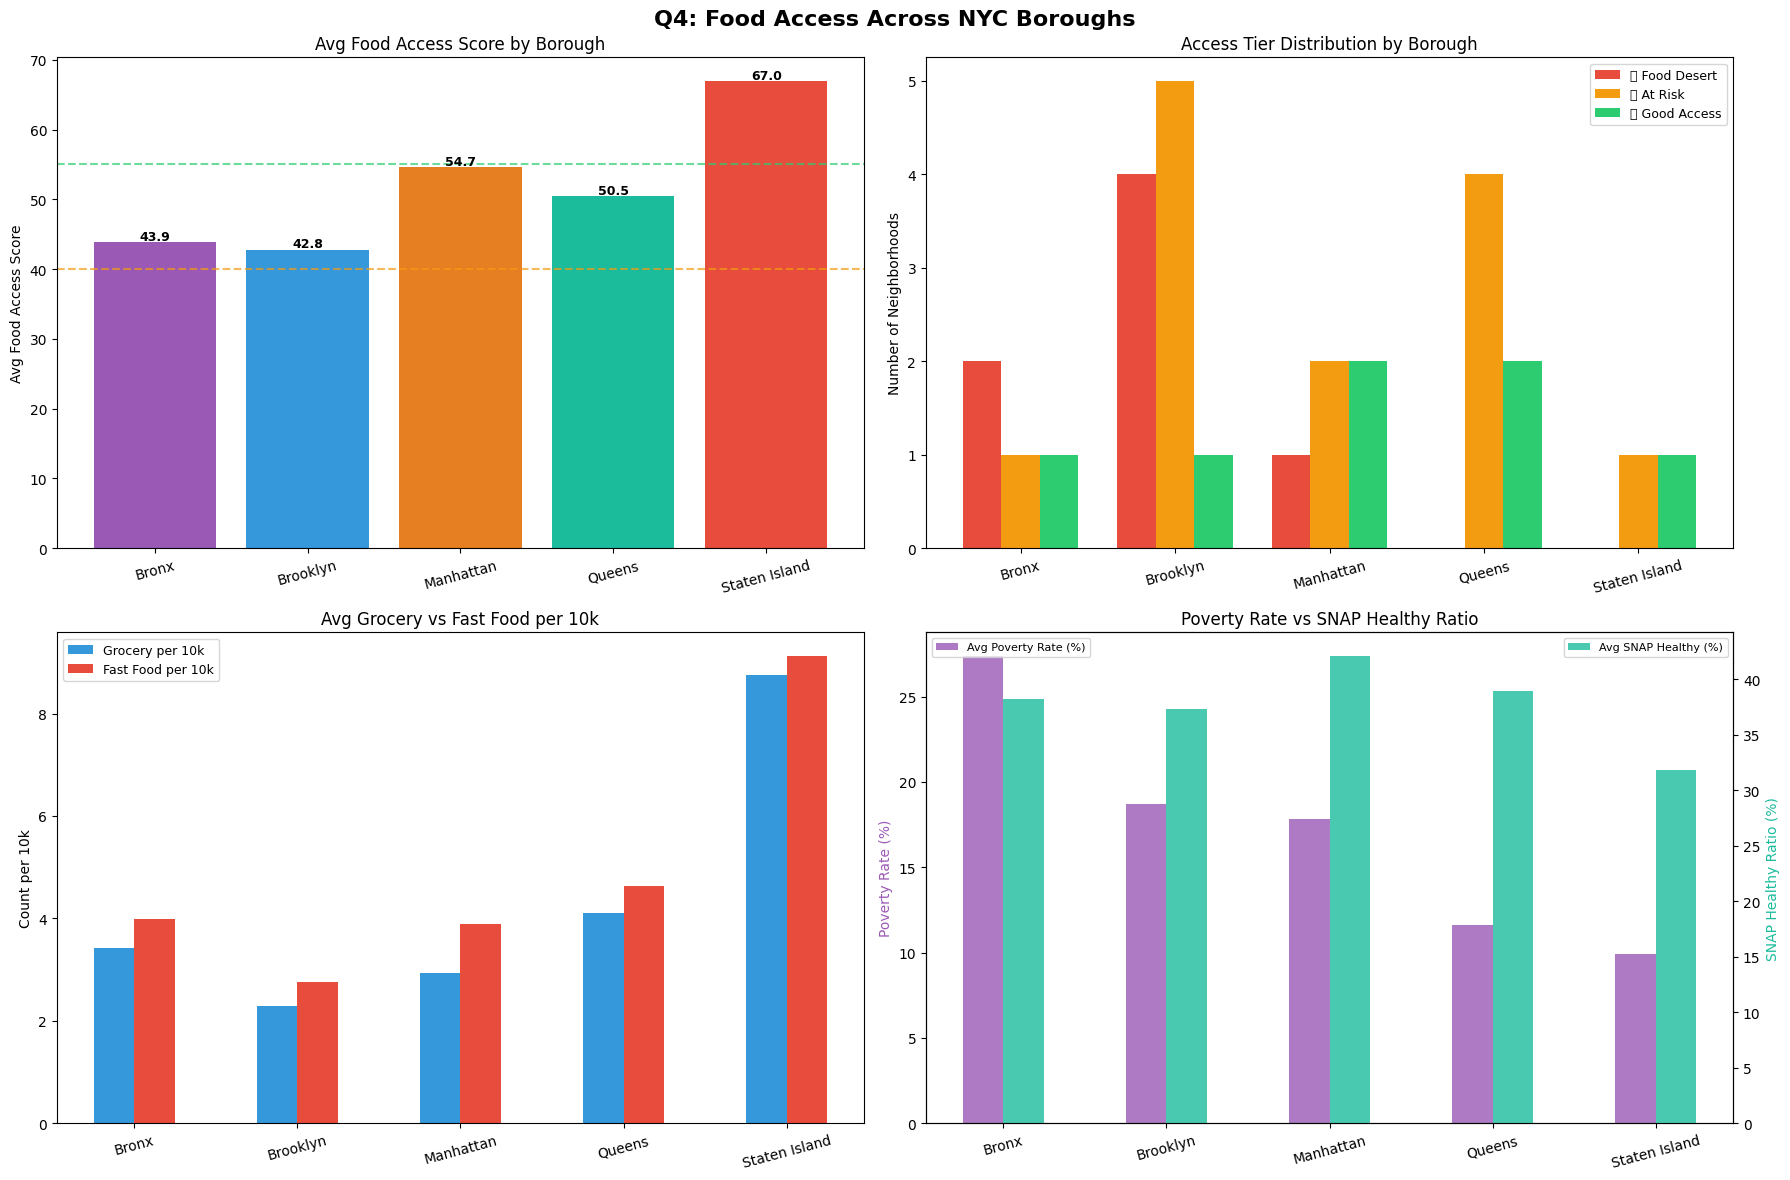

✅ Chart saved


In [7]:
# Q4 - Borough Level Food Access Comparison
borough_order = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
borough_palette = {
    "Bronx": "#9b59b6", "Brooklyn": "#3498db",
    "Manhattan": "#e67e22", "Queens": "#1abc9c",
    "Staten Island": "#e74c3c"
}

q4_df = summary_df.groupby("borough").agg(
    avg_score=("food_access_score", "mean"),
    avg_grocery_per_10k=("grocery_per_10k", "mean"),
    avg_fastfood_per_10k=("fastfood_per_10k", "mean"),
    avg_poverty=("poverty_rate", "mean"),
    avg_snap_healthy=("snap_healthy_ratio", "mean"),
    food_deserts=("our_food_desert", "sum"),
    total=("neighborhood", "count")
).reindex(borough_order).reset_index()

q4_df["at_risk"] = summary_df[summary_df["access_tier"] == "At Risk"].groupby("borough").size().reindex(borough_order).fillna(0).values
q4_df["good_access"] = summary_df[summary_df["access_tier"] == "Good Access"].groupby("borough").size().reindex(borough_order).fillna(0).values

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Q4: Food Access Across NYC Boroughs", fontsize=16, fontweight="bold")

colors = [borough_palette[b] for b in borough_order]

# Chart 1 - Avg Food Access Score by borough
bars = axes[0,0].bar(q4_df["borough"], q4_df["avg_score"], color=colors)
axes[0,0].axhline(y=55, color="#2ecc71", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0,0].axhline(y=40, color="#f39c12", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0,0].set_title("Avg Food Access Score by Borough")
axes[0,0].set_ylabel("Avg Food Access Score")
axes[0,0].tick_params(axis="x", rotation=15)
for bar, val in zip(bars, q4_df["avg_score"]):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                  f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")

# Chart 2 - Tier distribution per borough
x = range(len(borough_order))
width = 0.25
axes[0,1].bar([i - width for i in x], q4_df["food_deserts"],
              width, label="🔴 Food Desert", color="#e74c3c")
axes[0,1].bar([i for i in x], q4_df["at_risk"],
              width, label="🟡 At Risk", color="#f39c12")
axes[0,1].bar([i + width for i in x], q4_df["good_access"],
              width, label="🟢 Good Access", color="#2ecc71")
axes[0,1].set_xticks(list(x))
axes[0,1].set_xticklabels(borough_order, rotation=15)
axes[0,1].set_title("Access Tier Distribution by Borough")
axes[0,1].set_ylabel("Number of Neighborhoods")
axes[0,1].legend(fontsize=9)

# Chart 3 - Avg grocery vs fast food per 10k
x = range(len(borough_order))
axes[1,0].bar([i - width/2 for i in x], q4_df["avg_grocery_per_10k"],
              width, label="Grocery per 10k", color="#3498db")
axes[1,0].bar([i + width/2 for i in x], q4_df["avg_fastfood_per_10k"],
              width, label="Fast Food per 10k", color="#e74c3c")
axes[1,0].set_xticks(list(x))
axes[1,0].set_xticklabels(borough_order, rotation=15)
axes[1,0].set_title("Avg Grocery vs Fast Food per 10k")
axes[1,0].set_ylabel("Count per 10k")
axes[1,0].legend(fontsize=9)

# Chart 4 - Avg poverty rate and SNAP healthy ratio
ax4 = axes[1,1]
ax4b = ax4.twinx()
bars1 = ax4.bar([i - width/2 for i in x], q4_df["avg_poverty"],
                width, label="Avg Poverty Rate (%)", color="#9b59b6", alpha=0.8)
bars2 = ax4b.bar([i + width/2 for i in x], q4_df["avg_snap_healthy"],
                 width, label="Avg SNAP Healthy (%)", color="#1abc9c", alpha=0.8)
ax4.set_xticks(list(x))
ax4.set_xticklabels(borough_order, rotation=15)
ax4.set_title("Poverty Rate vs SNAP Healthy Ratio")
ax4.set_ylabel("Poverty Rate (%)", color="#9b59b6")
ax4b.set_ylabel("SNAP Healthy Ratio (%)", color="#1abc9c")
ax4.legend(loc="upper left", fontsize=8)
ax4b.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("q4_borough_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

---
## Interactive Map: NYC Food Access by Neighborhood

The map below visualizes all 27 neighborhoods using the three tier traffic 
light system. Each neighborhood boundary is shaded by access tier — green 
for Good Access, yellow for At Risk, and red for Food Desert. Clicking any 
neighborhood reveals its full Food Access Score, key metrics, and how it 
compares to the USDA classification.

The geographic distribution tells its own story — red and yellow neighborhoods 
cluster in the Bronx, central Brooklyn, and upper Manhattan, while green 
neighborhoods appear in wealthier areas and Staten Island's suburban south. 
The map makes visible what the USDA definition obscures: food insecurity in 
NYC is concentrated in dense, low-income urban neighborhoods where distance 
to a supermarket is rarely the barrier.

In [8]:
import requests
import folium

# Fetch ZIP code boundaries
r = requests.get("https://raw.githubusercontent.com/fedhere/PUI2015_EC/master/mam1612_EC/nyc-zip-code-tabulation-areas-polygons.geojson")
data = r.json()

# ZIP to neighborhood mapping
zip_to_neighborhood = {
    "10451": "South Bronx", "10454": "South Bronx", "10455": "South Bronx",
    "10452": "Highbridge", "10457": "Belmont", "10471": "Riverdale",
    "11207": "East New York", "11208": "East New York",
    "11221": "Bedford-Stuyvesant", "11233": "Bedford-Stuyvesant",
    "11213": "Crown Heights",
    "11205": "Clinton Hill / Fort Greene", "11201": "Clinton Hill / Fort Greene",
    "11231": "Red Hook",
    "11215": "Park Slope", "11217": "Park Slope",
    "11235": "Sheepshead Bay", "11224": "Coney Island",
    "11214": "Bensonhurst", "11230": "Midwood",
    "10032": "Washington Heights", "10033": "Washington Heights",
    "10037": "Harlem", "10039": "Harlem",
    "10023": "Upper West Side", "10024": "Upper West Side",
    "10003": "Greenwich Village", "10002": "Chinatown / Lower East Side",
    "11102": "Astoria", "11103": "Astoria",
    "11432": "Jamaica", "11433": "Jamaica",
    "11375": "Forest Hills", "11415": "Kew Gardens",
    "11379": "Middle Village", "11691": "Far Rockaway",
    "10301": "St. George", "10307": "Tottenville"
}

# Filter GeoJSON
filtered_features = [
    f for f in data["features"]
    if f["properties"]["postalCode"] in zip_to_neighborhood
]
print(f"✓ Matched {len(filtered_features)} ZIP code boundaries")

# Build neighborhood lookup
neighborhood_info = summary_df.set_index("neighborhood").to_dict(orient="index")

# Tier to map color
tier_map_colors = {
    "Good Access": "#2ecc71",
    "At Risk": "#f39c12",
    "Food Desert": "#e74c3c"
}

# Create map
m = folium.Map(location=[40.7308, -73.9352], zoom_start=11,
               tiles="CartoDB positron")

# Add ZIP boundaries
for feature in filtered_features:
    zip_code = feature["properties"]["postalCode"]
    neighborhood = zip_to_neighborhood.get(zip_code)
    if not neighborhood:
        continue

    info = neighborhood_info.get(neighborhood, {})
    tier = info.get("access_tier", "At Risk")
    fill_color = tier_map_colors.get(tier, "#f39c12")

    tier_emoji = "🟢" if tier == "Good Access" else "🟡" if tier == "At Risk" else "🔴"
    usda = "🏜️ Food Desert" if info.get("usda_food_desert") else "✅ Not a Desert"

    popup_html = f"""
    <div style="font-family: Arial; width: 250px;">
        <h4 style="margin-bottom:5px;">{neighborhood}</h4>
        <hr style="margin:4px 0">
        <b>Our Classification:</b> {tier_emoji} {tier}<br>
        <b>USDA Classification:</b> {usda}<br>
        <b>Food Access Score:</b> {info.get('food_access_score', 'N/A')}<br>
        <hr style="margin:4px 0">
        <b>Population:</b> {int(info.get('total_population', 0)):,}<br>
        <b>Median Income:</b> ${int(info.get('avg_median_income', 0)):,}<br>
        <b>Poverty Rate:</b> {info.get('poverty_rate', 0)}%<br>
        <b>Groceries per 10k:</b> {info.get('grocery_per_10k', 0)}<br>
        <b>Fast Food per 10k:</b> {info.get('fastfood_per_10k', 0)}<br>
        <b>SNAP Healthy Ratio:</b> {info.get('snap_healthy_ratio', 0)}%<br>
        <b>Year-Round Markets:</b> {int(info.get('year_round_markets', 0))}<br>
        <b>% Grade A:</b> {info.get('pct_grade_A', 0)}%
    </div>
    """

    folium.GeoJson(
        feature,
        style_function=lambda x, fc=fill_color: {
            "fillColor": fc,
            "color": "white",
            "weight": 2,
            "fillOpacity": 0.65
        },
        tooltip=f"{neighborhood} — {tier_emoji} {tier} (Score: {info.get('food_access_score', 'N/A')})",
        popup=folium.Popup(popup_html, max_width=260)
    ).add_to(m)

# Legend
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 2px solid grey; font-family: Arial; font-size: 13px;">
    <b>NYC Food Access Map</b><br><br>
    <span style="color:#2ecc71;">●</span> 🟢 Good Access (≥55)<br>
    <span style="color:#f39c12;">●</span> 🟡 At Risk (40-54)<br>
    <span style="color:#e74c3c;">●</span> 🔴 Food Desert (<40)<br><br>
    <i>Click a neighborhood for details</i>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save("fooddesert_map.html")
m

✓ Matched 39 ZIP code boundaries


---
## Conclusions

The data collected across 27 NYC neighborhoods supports the central thesis: 
**the USDA's distance-based definition of food deserts systematically 
undercounts food insecurity in dense urban environments.**

### Key Findings

**1. The USDA Definition Fails NYC**
The Bronx, Manhattan, and Queens each have zero USDA food deserts despite 
containing some of the most food-insecure communities in the country. Staten 
Island — the wealthiest, most suburban borough — accounts for 28 of NYC's 
33 USDA food deserts simply because its layout stretches distances beyond 
1 mile. The 1-mile threshold was designed for rural America. In NYC it 
measures the wrong thing entirely.

**2. 7 Neighborhoods Are Genuine Food Deserts**
South Bronx, Harlem, Bedford-Stuyvesant, Sheepshead Bay, Crown Heights, 
Clinton Hill/Fort Greene, and Belmont score below 40 on the Food Access 
Score. These neighborhoods share a common profile — low grocery density, 
high fast food concentration, high poverty rates, and SNAP retailers 
dominated by convenience stores rather than actual food stores.

**3. 13 Neighborhoods Are At Risk**
Nearly half the study sits in the At Risk tier — not yet food deserts but 
showing clear warning signs. East New York, Highbridge, and Crown Heights 
sit just above the Food Desert threshold. As gentrification continues to 
displace informal food infrastructure like bodegas and fruit stands, these 
neighborhoods are vulnerable to tipping over.

**4. Bodegas and Convenience Stores Are Not a Solution**
Across all 27 neighborhoods, convenience stores account for 43% of all 
SNAP-authorized retailers. In Bedford-Stuyvesant, 74.5% of SNAP retailers 
are convenience stores. Food assistance dollars are being spent at 
establishments that primarily sell processed goods — proximity to a SNAP 
retailer does not equal access to nutritious food.

**5. Farmers Markets Help But Are Mostly Seasonal**
South Bronx has 42 farmers markets — the most of any neighborhood — yet 
only 1 operates year-round. Upper West Side has 19 year-round markets. 
The presence of farmers markets improves the food environment but seasonal 
markets cannot serve as a primary food source for communities that depend 
on them.

**6. Income Does Not Determine Food Access**
Greenwich Village has a median income of 153k yet scores as At Risk. 
Washington Heights has a median income of 66k yet also scores At Risk. 
The relationship between wealth and food access is not linear in NYC — 
neighborhood density, land use, and the economics of urban retail shape 
the food environment independently of resident income.

---

### Problems Encountered & Technical Decisions

Full data completeness cannot be verified since there is 
no ground truth dataset listing every food establishment in NYC — Google 
Places caps at 60 results per query, newer or informal establishments may 
not be listed, and the bodega search type was found to miscategorize suburban 
convenience stores, requiring it to be removed from the Food Access Score 
formula entirely. 

ZIP code tabulation areas were chosen as the geographic 
unit over neighborhood names or radius searches because they are officially 
defined boundaries that map directly to NYC Open Data datasets and allow 
multiple ZIP codes per neighborhood for fuller coverage.

---

### Limitations
- Google Places caps at 60 results per query — full establishment coverage 
  cannot be verified
- Only 27 of NYC's 300+ neighborhoods were studied — findings are 
  illustrative rather than exhaustive
- ZIP codes approximate neighborhood boundaries — some cover multiple 
  distinct areas
- USDA Food Access Research Atlas data is from 2019 — some classifications 
  may have changed
- Tottenville's small population (14,821) inflates its grocery per 10k 
  metric, artificially boosting its score

---

### Future Work
- **Expand coverage** — include all 300+ NYC neighborhoods for a true 
  city-wide analysis, then expand the methodology to other major U.S. cities 
  to test whether the USDA definition fails in other dense urban environments 
  beyond NYC
- **Add community resources** — incorporate NYC community garden locations 
  and food pantry data as additional dimensions of food access, recognizing 
  that informal community infrastructure plays a critical role in underserved 
  neighborhoods
- **Food delivery apps** — analyze whether platforms like DoorDash, Uber 
  Eats, and Instacart are bridging the food access gap in food desert 
  neighborhoods or whether delivery fees, minimum orders, and tipping 
  requirements make them inaccessible to low-income residents — and whether 
  the same dynamic holds in suburban and rural areas outside NYC
- **Time-series analysis** — track how Food Access Scores change over time 
  as gentrification reshapes neighborhoods, measuring whether the arrival 
  of new food retail displaces or supplements existing informal food 
  infrastructure
- **Real-time dashboard** — build a live dashboard that updates automatically 
  as new Google Places, SNAP retailer, farmers market, and inspection data 
  becomes available

In [9]:
# Final Summary Table
print("=" * 80)
print("FINAL SUMMARY — NYC FOOD DESERT ANALYSIS")
print("=" * 80)

final_df = summary_df[[
    "neighborhood",
    "borough",
    "total_population",
    "avg_median_income",
    "poverty_rate",
    "grocery_per_10k",
    "fastfood_per_10k",
    "grocery_to_fastfood_ratio",
    "snap_healthy_ratio",
    "year_round_markets",
    "pct_grade_A",
    "food_access_score",
    "access_tier",
    "usda_food_desert"
]].copy()

final_df = final_df.sort_values("food_access_score", ascending=False)

final_df.columns = [
    "Neighborhood", "Borough", "Population", "Median Income",
    "Poverty Rate (%)", "Groceries per 10k", "Fast Food per 10k",
    "Grocery/FastFood Ratio", "SNAP Healthy (%)", "Year-Round Markets",
    "% Grade A", "Food Access Score", "Access Tier", "USDA Classification"
]

final_df["Population"] = final_df["Population"].apply(lambda x: f"{x:,.0f}")
final_df["Median Income"] = final_df["Median Income"].apply(lambda x: f"${x:,.0f}")
final_df["Access Tier"] = final_df["Access Tier"].apply(lambda x:
    "🟢 Good Access" if x == "Good Access" else
    "🟡 At Risk" if x == "At Risk" else
    "🔴 Food Desert"
)
final_df["USDA Classification"] = final_df["USDA Classification"].apply(
    lambda x: "🏜️ Food Desert" if x else "✅ Not a Desert"
)

display(final_df)

print("\n📊 Key Statistics:")
print(f"  Total neighborhoods studied:              {len(summary_df)}")
print(f"  🟢 Good Access neighborhoods:             {(summary_df['access_tier'] == 'Good Access').sum()}")
print(f"  🟡 At Risk neighborhoods:                 {(summary_df['access_tier'] == 'At Risk').sum()}")
print(f"  🔴 Food Desert neighborhoods:             {(summary_df['access_tier'] == 'Food Desert').sum()}")
print(f"  Total food establishments collected:      {len(places_df):,}")
print(f"  Total inspections analyzed:               {len(inspections_df):,}")
print(f"  Total SNAP retailers analyzed:            {len(snap_df):,}")
print(f"  Total farmers markets analyzed:           {len(farmers_df):,}")
print(f"  USDA food deserts in NYC:                 33 (across 2,227 census tracts)")
print(f"  Bronx USDA food deserts:                  0")
print(f"  Manhattan USDA food deserts:              0")
print(f"  Queens USDA food deserts:                 0")
print(f"  Highest Food Access Score:                {summary_df.loc[summary_df['food_access_score'].idxmax(), 'neighborhood']} ({summary_df['food_access_score'].max():.2f})")
print(f"  Lowest Food Access Score:                 {summary_df.loc[summary_df['food_access_score'].idxmin(), 'neighborhood']} ({summary_df['food_access_score'].min():.2f})")
print(f"  Avg SNAP healthy ratio — Food Deserts:    {summary_df[summary_df['access_tier'] == 'Food Desert']['snap_healthy_ratio'].mean():.1f}%")
print(f"  Avg SNAP healthy ratio — Good Access:     {summary_df[summary_df['access_tier'] == 'Good Access']['snap_healthy_ratio'].mean():.1f}%")
print(f"  Convenience stores % of SNAP retailers:   {(snap_df['Store_Type'] == 'Convenience Store').sum() / len(snap_df) * 100:.1f}%")

FINAL SUMMARY — NYC FOOD DESERT ANALYSIS


,Neighborhood,Borough,Population,Median Income,Poverty Rate (%),Groceries per 10k,Fast Food per 10k,Grocery/FastFood Ratio,SNAP Healthy (%),Year-Round Markets,% Grade A,Food Access Score,Access Tier,USDA Classification
24,Tottenville,Staten Island,"14,821","$138,807",2.7,13.49,13.49,1.00,33.3,0.0,87.0,87.20,🟢 Good Access,🏜️ Food Desert
25,Upper West Side,Manhattan,"130,044","$170,240",8.0,2.00,2.85,0.70,54.8,19.0,94.2,77.32,🟢 Good Access,✅ Not a Desert
20,Riverdale,Bronx,"23,400","$108,738",5.4,7.26,7.26,1.00,37.5,1.0,90.0,71.23,🟢 Good Access,✅ Not a Desert
18,Park Slope,Brooklyn,"113,491","$169,544",7.5,3.00,3.35,0.90,43.3,10.0,93.4,63.95,🟢 Good Access,🏜️ Food Desert
11,Greenwich Village,Manhattan,"53,825","$153,750",10.4,2.97,3.72,0.80,43.3,7.0,94.4,59.56,🟢 Good Access,✅ Not a Desert
15,Kew Gardens,Queens,"21,379","$88,632",9.3,8.42,9.35,0.90,21.4,0.0,93.8,56.64,🟢 Good Access,✅ Not a Desert
16,Middle Village,Queens,"37,378","$92,509",7.2,4.82,5.08,0.95,41.2,0.0,96.6,55.48,🟢 Good Access,✅ Not a Desert
10,Forest Hills,Queens,"75,320","$104,319",7.9,1.59,2.52,0.63,50.0,7.0,93.1,53.59,🟡 At Risk,✅ Not a Desert
0,Astoria,Queens,"63,706","$97,892",11.1,4.08,4.87,0.84,46.8,0.0,93.1,52.00,🟡 At Risk,✅ Not a Desert
26,Washington Heights,Manhattan,"109,190","$66,086",18.2,2.11,3.02,0.70,48.1,6.0,93.0,51.64,🟡 At Risk,✅ Not a Desert



📊 Key Statistics:
  Total neighborhoods studied:              27
  🟢 Good Access neighborhoods:             7
  🟡 At Risk neighborhoods:                 13
  🔴 Food Desert neighborhoods:             7
  Total food establishments collected:      2,315
  Total inspections analyzed:               65,959
  Total SNAP retailers analyzed:            2,410
  Total farmers markets analyzed:           2,115
  USDA food deserts in NYC:                 33 (across 2,227 census tracts)
  Bronx USDA food deserts:                  0
  Manhattan USDA food deserts:              0
  Queens USDA food deserts:                 0
  Highest Food Access Score:                Tottenville (87.20)
  Lowest Food Access Score:                 South Bronx (27.39)
  Avg SNAP healthy ratio — Food Deserts:    32.9%
  Avg SNAP healthy ratio — Good Access:     39.3%
  Convenience stores % of SNAP retailers:   43.4%
